In [1]:
import libs.append_path
from add_python_libraries import *
import scipy as sp

from capacitor_selection_tables import Cap_selector
from cyntec import Inductor_pdis
from current_buck_waveforms import Current_buck_waveforms
from current_carova_MR_waveforms import Current_carova_MR_waveforms
from capbanks_audible_a_vs_b import InputCapbanks, InputCapbanks_a_vs_b

In [2]:
input_params = {'vin' : 28,
                'vout': 11.1,
                'pin' : 165, 
                'eff' : 0.96, 
                'fs'  :300e3,
                'ton_mult':1,
                #'ddiv':4,
                'tambient':25,
                'lout':{'family'   :'cmle104t',#'hbed053t',
                        'value(uH)':1,
                        'config'   :'single'},
                'lvl_config':'3 level carova',
               }
input_params['iout'] = input_params['pin']*input_params['eff']/input_params['vout']
vbias = input_params['vin']
lobj = Inductor_pdis(input_params)
iobj = {True:Current_carova_MR_waveforms,
        False:Current_buck_waveforms}[lobj.ckt['state count']==6](lobj)
cap_selector_obj = Cap_selector(vbias)

## Select MLCC cap quantity and series config

In [3]:
datagrid_mlcc = cap_selector_obj.create_mlcc_selection_table_ab()
datagrid_mlcc

DataGrid(auto_fit_columns=True, auto_fit_params={'area': 'all', 'padding': 30, 'numCols': None}, corner_render…

In [ ]:
cap_selector_obj.save_to_file(datagrid_mlcc,'capbanks/280w_mlcc.csv')#165w_mlcc_ZRB.csv')

In [13]:
cap_selector_obj.load_from_file(datagrid_mlcc,'capbanks/165w_mlcc.csv')#165w_mlcc_KRM.csv')

## Select SP cap quantity (last column)

In [5]:
datagrid_sp = cap_selector_obj.create_sp_selection_table_ab()
datagrid_sp

DataGrid(auto_fit_columns=True, auto_fit_params={'area': 'all', 'padding': 30, 'numCols': None}, corner_render…

In [ ]:
datagrid_sp.selected_cells

In [ ]:
cap_selector_obj.save_to_file(datagrid_sp,'capbanks/280w_sp.csv') #65W_sp_ZRB.csv')

In [14]:
cap_selector_obj.load_from_file(datagrid_sp,'capbanks/165w_sp.csv')#65W_sp_ZRB.csv')

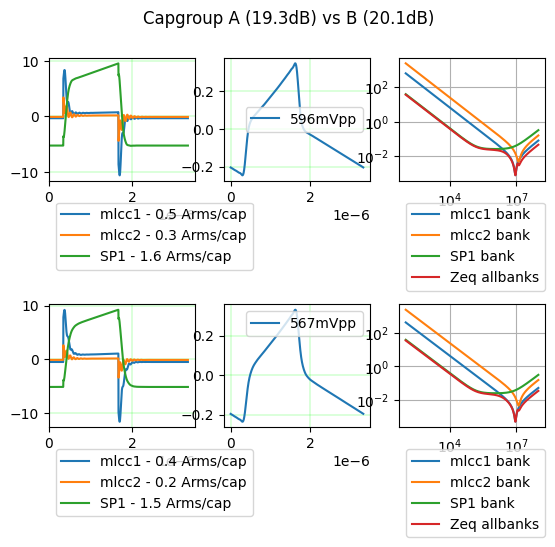

In [15]:
df_a = cap_selector_obj.create_allcaps_selected_df(datagrid_mlcc,datagrid_sp,'a')
df_b = cap_selector_obj.create_allcaps_selected_df(datagrid_mlcc,datagrid_sp,'b')
inpcaps_a = InputCapbanks(iobj,df_a)
inpcaps_b = InputCapbanks(iobj,df_b)

db_0603_500mV = 10  #base sound level of a single 0603 cap with 500mVpp voltage

inpcaps_a_vs_b = InputCapbanks_a_vs_b(inpcaps_a,inpcaps_b,db_0603_500mV)
afig=inpcaps_a_vs_b.plots_a_vs_b()

In [8]:
inpcaps_a_vs_b.df_a

,key,partnum,type,qnty,series,package,temp,volt rating,cap_uF(@0V),cap_uF(@vbias),ESR_mOhm,ESL_nH,Irms_A,ceq,x,y,label,sound factor(dB)
0,15,GRM188R6YA106MA73,mlcc,4,0,0603,X5R,35.0,10.0,0.609,3.0,0.5,,2.436,12.0,6,mlcc1,17.5
1,21,GRM188C8YA225ME11,mlcc,2,0,0603,X6S,35.0,2.2,0.317,9.0,0.5,,0.634,6.0,6,mlcc2,14.5
2,6,T521B106M035ATE100,SP,4,0,B,125,35.0,,10.000,100.0,2.0,1.41,40.000,44.0,13,SP1,0.0


In [9]:
inpcaps_a_vs_b.df_b

,key,partnum,type,qnty,series,package,temp,volt rating,cap_uF(@0V),cap_uF(@vbias),ESR_mOhm,ESL_nH,Irms_A,ceq,x,y,label,sound factor(dB)
0,15,GRM188R6YA106MA73,mlcc,6,0,0603,X5R,35.0,10.0,0.609,3.0,0.5,,3.654,18.0,6,mlcc1,18.9
1,21,GRM188C8YA225ME11,mlcc,2,0,0603,X6S,35.0,2.2,0.317,9.0,0.5,,0.634,6.0,6,mlcc2,14.1
2,6,T521B106M035ATE100,SP,4,0,B,125,35.0,,10.000,100.0,2.0,1.41,40.000,44.0,13,SP1,0.0


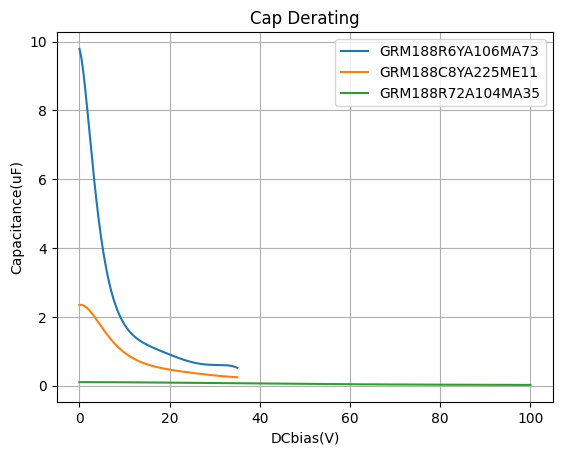

In [10]:
cap_obj_list = cap_selector_obj.cap_obj_list
x = 'DCbias(V)'; y='Capacitance(uF)'; title='Cap Derating'
ax=cap_obj_list[0].df_cap_vs_bias.plot(x=x,y=y,title=title, label=cap_obj_list[0].df_param.partnum[0])
for idx,cap_obj in enumerate(cap_obj_list):
    if idx !=0:
        cap_obj.df_cap_vs_bias.plot(ax=ax,x=x,y=y,title=title, label=cap_obj.df_param.partnum[0])
        
ax.set_ylabel('Capacitance(uF)')
ax.grid(True)

In [ ]:
inpcaps_a_vs_b.export_to_excel(inpcaps_a_vs_b.df_a,inpcaps_a_vs_b.df_b,afig)